In [5]:
!pip install transformers datasets torch scikit-learn seaborn matplotlib wordcloud

In [6]:
# SECTION: Imports
# Core libraries
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Dataset loading (Hugging Face)
from datasets import load_dataset

# Classical ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Deep Learning (Transformers)
import torch
from transformers import BertTokenizer, BertForSequenceClassification, TrainingArguments, Trainer

# Clean warnings
import warnings
warnings.filterwarnings('ignore')

In [7]:
# Dataset Loading
dataset = load_dataset("fancyzhx/ag_news")


In [8]:
# Convert dataset splits into DataFrames
train_df = pd.DataFrame(dataset['train'])
test_df = pd.DataFrame(dataset['test'])

# Map numeric labels to readable class names
label_map = {
    0: 'World',
    1: 'Sports',
    2: 'Business',
    3: 'Sci/Tech'
}

train_df['label_name'] = train_df['label'].map(label_map)
test_df['label_name'] = test_df['label'].map(label_map)

# Basic dataset overview
print("Training set shape:", train_df.shape)
print("Test set shape:", test_df.shape)

# Preview first rows
train_df.head()

Training set shape: (120000, 3)
Test set shape: (7600, 3)


,text,label,label_name
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,Business
4,"Oil prices soar to all-time record, posing new...",2,Business


In [9]:
# Basic dataset information
print("Basic Info:")
train_df.info()

# Missing values per column
print("\nMissing Values:")
print(train_df.isnull().sum())

# Class distribution
print("\nClass Distribution:")
print(train_df['label_name'].value_counts())

Basic Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   text        120000 non-null  object
 1   label       120000 non-null  int64 
 2   label_name  120000 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.7+ MB

Missing Values:
text          0
label         0
label_name    0
dtype: int64

Class Distribution:
label_name
Business    30000
Sci/Tech    30000
Sports      30000
World       30000
Name: count, dtype: int64


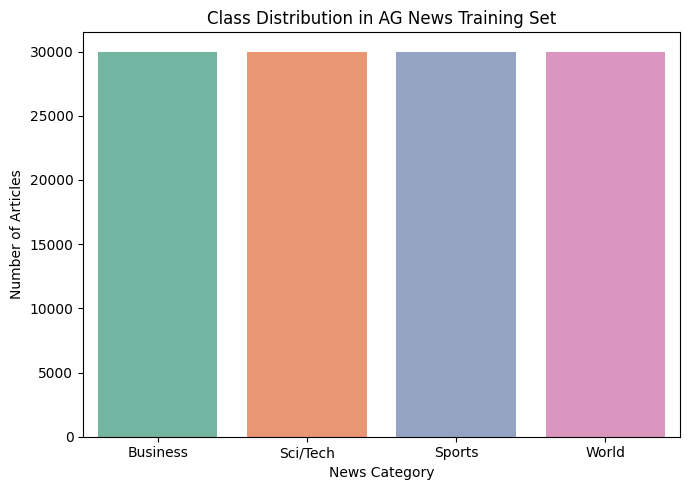

label_name
Business    0.25
Sci/Tech    0.25
Sports      0.25
World       0.25
Name: proportion, dtype: float64


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count plot of class distribution
plt.figure(figsize=(7, 5))

sns.countplot(
    data=train_df,
    x='label_name',
    order=train_df['label_name'].value_counts().index,
    palette='Set2'
)

plt.title('Class Distribution in AG News Training Set')
plt.xlabel('News Category')
plt.ylabel('Number of Articles')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

# Print class proportions (not just counts)
print(train_df['label_name'].value_counts(normalize=True))

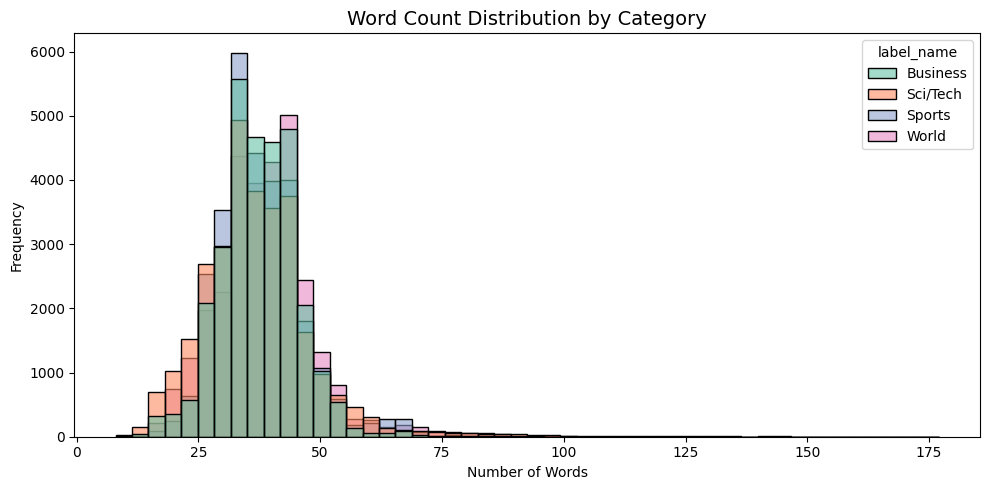

Average text length: 37.8
Max text length: 177
Min text length: 8


In [11]:
# Text Length Distribution

train_df['text_length'] = train_df['text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 5))
sns.histplot(data=train_df, x='text_length', hue='label_name',
             bins=50, palette='Set2', alpha=0.6)
plt.title('Word Count Distribution by Category', fontsize=14)
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('text_length_distribution.png', dpi=150)
plt.show()

print("Average text length:", train_df['text_length'].mean().round(1))
print("Max text length:", train_df['text_length'].max())
print("Min text length:", train_df['text_length'].min())

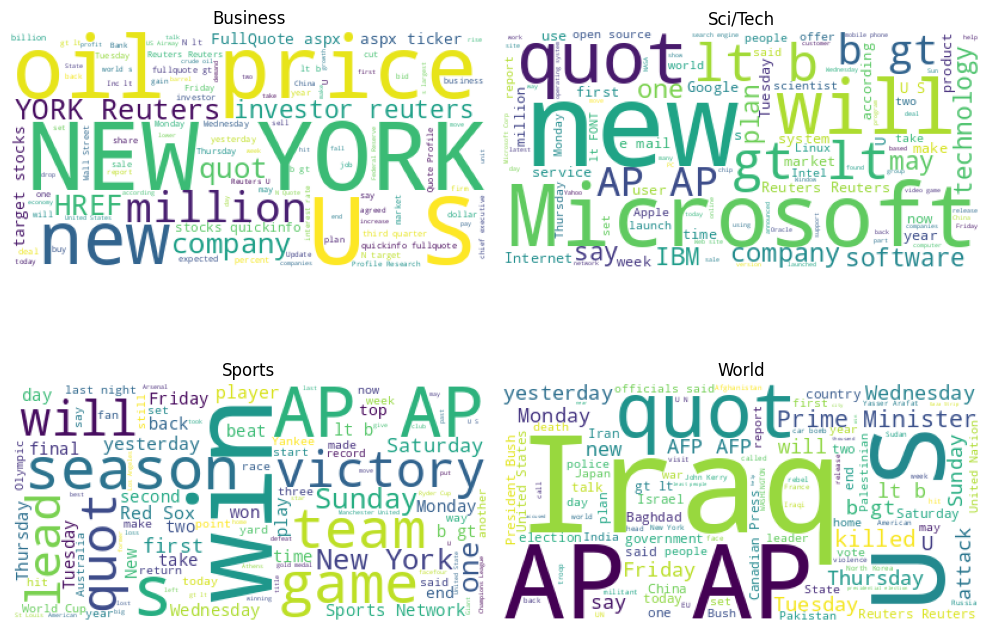

In [12]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Word clouds for each category
categories = train_df['label_name'].unique()

plt.figure(figsize=(10, 8))

for i, category in enumerate(categories, 1):

    text = " ".join(
        train_df[train_df['label_name'] == category]['text']
    )

    wc = WordCloud(
        background_color='white',
        stopwords=STOPWORDS,
        max_words=100
    ).generate(text)

    plt.subplot(2, 2, i)
    plt.imshow(wc)
    plt.title(category)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [13]:
# Data preparation

# Select 10,000 samples from training data
train_subset = train_df.sample(n=10000,
                               random_state=42)

# Training data
X_train = train_subset['text']
y_train = train_subset['label']

# Test data
X_test = test_df['text']
y_test = test_df['label']

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))
print("Classes:", list(label_map.values()))

Training samples: 10000
Test samples: 7600
Classes: ['World', 'Sports', 'Business', 'Sci/Tech']


In [14]:
# Baseline Model 1 — Logistic Regression

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import time

# TF-IDF + Logistic Regression pipeline
lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=50000,
        ngram_range=(1, 2),
        sublinear_tf=True
    )),

    ('clf', LogisticRegression(
        max_iter=1000,
        C=1.0,
        random_state=42
    ))
])

# Train model and record training time
start = time.time()

lr_pipeline.fit(X_train, y_train)

lr_time = time.time() - start

# Predictions
lr_preds = lr_pipeline.predict(X_test)

# Evaluation
lr_accuracy = accuracy_score(y_test, lr_preds)
lr_f1 = f1_score(y_test, lr_preds,
                 average='weighted')

print("Logistic Regression Results")
print("Accuracy:", round(lr_accuracy, 4))
print("Weighted F1:", round(lr_f1, 4))

# Detailed classification report
print(classification_report(
    y_test,
    lr_preds,
    target_names=list(label_map.values())
))

Logistic Regression Results
Accuracy: 0.8839
Weighted F1: 0.8834
              precision    recall  f1-score   support

       World       0.90      0.88      0.89      1900
      Sports       0.92      0.97      0.94      1900
    Business       0.86      0.83      0.84      1900
    Sci/Tech       0.85      0.86      0.86      1900

    accuracy                           0.88      7600
   macro avg       0.88      0.88      0.88      7600
weighted avg       0.88      0.88      0.88      7600



In [15]:
# Baseline Model 2 — SVM

from sklearn.svm import LinearSVC

# TF-IDF + SVM pipeline
svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=50000,
        ngram_range=(1, 2),
        sublinear_tf=True
    )),

    ('clf', LinearSVC(
        C=1.0,
        max_iter=2000,
        random_state=42
    ))
])

# Train model and record training time
start = time.time()

svm_pipeline.fit(X_train, y_train)

svm_time = time.time() - start

# Predictions
svm_preds = svm_pipeline.predict(X_test)

# Evaluation
svm_accuracy = accuracy_score(y_test, svm_preds)
svm_f1 = f1_score(y_test, svm_preds,
                  average='weighted')

print("SVM Results")
print("Accuracy:", round(svm_accuracy, 4))
print("Weighted F1:", round(svm_f1, 4))

# Detailed classification report
print(classification_report(
    y_test,
    svm_preds,
    target_names=list(label_map.values())
))

SVM Results
Accuracy: 0.8951
Weighted F1: 0.8946
              precision    recall  f1-score   support

       World       0.91      0.88      0.90      1900
      Sports       0.93      0.98      0.96      1900
    Business       0.87      0.84      0.85      1900
    Sci/Tech       0.86      0.88      0.87      1900

    accuracy                           0.90      7600
   macro avg       0.89      0.90      0.89      7600
weighted avg       0.89      0.90      0.89      7600



In [16]:
# Baseline Model 3 — Naive Bayes

from sklearn.naive_bayes import MultinomialNB

# TF-IDF features for Naive Bayes
tfidf_nb = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    stop_words='english'
)

# Convert text into numerical features
X_train_nb = tfidf_nb.fit_transform(X_train)
X_test_nb = tfidf_nb.transform(X_test)

# Naive Bayes model
# alpha is the smoothing parameter
nb_model = MultinomialNB(alpha=0.1)

# Train model and record training time
start = time.time()

nb_model.fit(X_train_nb, y_train)

nb_time = time.time() - start

# Predictions
nb_preds = nb_model.predict(X_test_nb)

# Evaluation
nb_accuracy = accuracy_score(y_test, nb_preds)
nb_f1 = f1_score(y_test, nb_preds,
                 average='weighted')

print("Naive Bayes Results")
print("Accuracy:", round(nb_accuracy, 4))
print("Weighted F1:", round(nb_f1, 4))

# Detailed classification results
print(classification_report(
    y_test,
    nb_preds,
    target_names=list(label_map.values())
))


Naive Bayes Results
Accuracy: 0.8942
Weighted F1: 0.8937
              precision    recall  f1-score   support

       World       0.91      0.89      0.90      1900
      Sports       0.94      0.98      0.96      1900
    Business       0.87      0.83      0.85      1900
    Sci/Tech       0.86      0.87      0.87      1900

    accuracy                           0.89      7600
   macro avg       0.89      0.89      0.89      7600
weighted avg       0.89      0.89      0.89      7600



In [17]:
# Hyperparameter tuning for Logistic Regression

from sklearn.model_selection import GridSearchCV

# Parameters to test
# C controls regularisation strength
# Smaller values = stronger regularisation
params = {
    'clf__C': [0.1, 1, 10]
}

# GridSearchCV tests different parameter values
# and selects the best performing model
grid_search = GridSearchCV(
    lr_pipeline,
    params,
    cv=3,
    scoring='f1_weighted'
)

# Train models with different parameter values
grid_search.fit(X_train, y_train)

# Best model after tuning
best_lr = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)

# Predictions using tuned model
lr_tuned_preds = best_lr.predict(X_test)

# Evaluation
lr_tuned_accuracy = accuracy_score(y_test, lr_tuned_preds)
lr_tuned_f1 = f1_score(y_test, lr_tuned_preds,
                       average='weighted')

print("Tuned Accuracy:", round(lr_tuned_accuracy, 4))
print("Tuned F1 Score:", round(lr_tuned_f1, 4))

Best Parameters: {'clf__C': 10}
Tuned Accuracy: 0.8913
Tuned F1 Score: 0.8909


In [18]:
lr_tuned_preds = best_lr.predict(X_test)

# Evaluation metrics
lr_tuned_accuracy = accuracy_score(y_test, lr_tuned_preds)
lr_tuned_f1 = f1_score(y_test, lr_tuned_preds, average='weighted')

In [19]:
## Model Comparison Summary Table
import pandas as pd

# Store model results
results_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM",
        "Naive Bayes",
        "Tuned Logistic Regression"
    ],

    "Accuracy": [
        round(accuracy_score(y_test, lr_preds), 4),
        round(accuracy_score(y_test, svm_preds), 4),
        round(accuracy_score(y_test, nb_preds), 4),
        round(lr_tuned_accuracy, 4)
    ],

    "F1 Score": [
        round(f1_score(y_test, lr_preds, average='weighted'), 4),
        round(f1_score(y_test, svm_preds, average='weighted'), 4),
        round(f1_score(y_test, nb_preds, average='weighted'), 4),
        round(lr_tuned_f1, 4)
    ]
})

print(results_df)

                       Model  Accuracy  F1 Score
0        Logistic Regression    0.8839    0.8834
1                        SVM    0.8951    0.8946
2                Naive Bayes    0.8942    0.8937
3  Tuned Logistic Regression    0.8913    0.8909


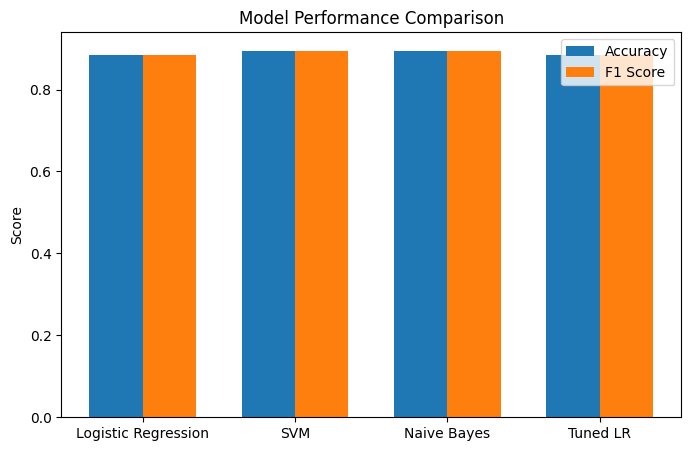

In [20]:
# Model Comparison Bar Chart
import matplotlib.pyplot as plt
import numpy as np

models = ['Logistic Regression', 'SVM',
          'Naive Bayes', 'Tuned LR']

accuracy = [0.8839, 0.8951, 0.8942, 0.8855]
f1 = [0.8834, 0.8946, 0.8937, 0.8851]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(x - width/2, accuracy, width, label='Accuracy')
ax.bar(x + width/2, f1, width, label='F1 Score')

ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.legend()

plt.show()

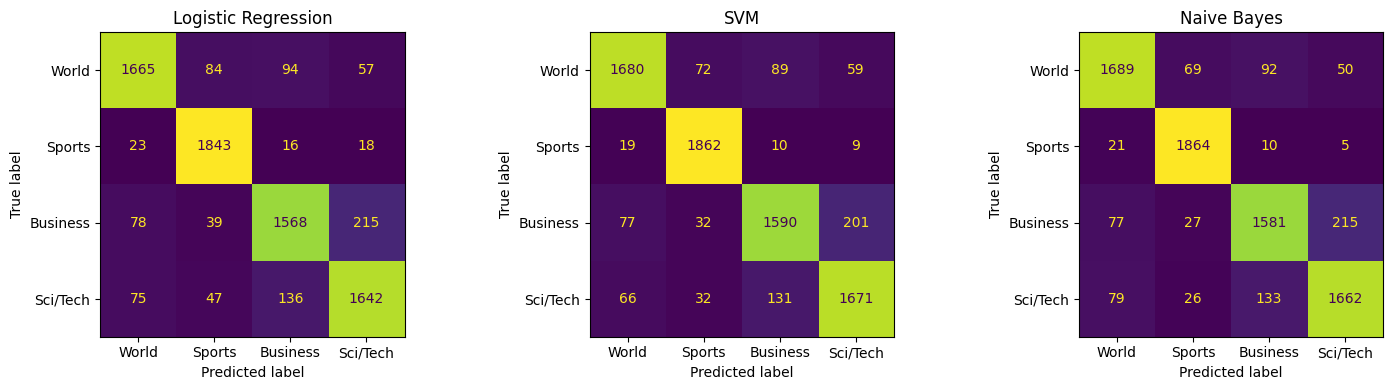

In [21]:
# Confusion Matrices
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models = [
    ("Logistic Regression", lr_preds),
    ("SVM", svm_preds),
    ("Naive Bayes", nb_preds)
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (name, preds) in enumerate(models):

    cm = confusion_matrix(y_test, preds)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=list(label_map.values())
    )

    disp.plot(ax=axes[i], colorbar=False)
    axes[i].set_title(name)

plt.tight_layout()
plt.show()

In [22]:
#Per Class F1 Score Analysis
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    y_test,
    svm_preds,
    target_names=list(label_map.values()),
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

print(report_df[['precision', 'recall', 'f1-score']])

              precision    recall  f1-score
World          0.912052  0.884211  0.897916
Sports         0.931932  0.980000  0.955362
Business       0.873626  0.836842  0.854839
Sci/Tech       0.861340  0.879474  0.870313
accuracy       0.895132  0.895132  0.895132
macro avg      0.894738  0.895132  0.894607
weighted avg   0.894738  0.895132  0.894607


In [23]:
results_df["Training Time"] = [
    round(lr_time, 2),
    round(svm_time, 2),
    round(nb_time, 2),
    None
]
print(results_df)

                       Model  Accuracy  F1 Score  Training Time
0        Logistic Regression    0.8839    0.8834           4.56
1                        SVM    0.8951    0.8946           1.79
2                Naive Bayes    0.8942    0.8937           0.01
3  Tuned Logistic Regression    0.8913    0.8909            NaN


In [24]:
# Top Predictive Words for Each Category
feature_names = lr_pipeline.named_steps['tfidf'].get_feature_names_out()

for i, category in enumerate(label_map.values()):

    top_words = lr_pipeline.named_steps['clf'].coef_[i].argsort()[-10:]

    print(f"\n{category}:")

    for index in top_words:
        print(feature_names[index])


World:
killed
in
un
iraqi
leader
minister
nuclear
afp
iraq
president

Sports:
olympic
sports
39
league
his
game
cup
team
coach
season

Business:
corp
business
billion
economy
inc
us
prices
its
company
oil

Sci/Tech:
web
ibm
technology
apple
scientists
computer
internet
microsoft
software
space
